# PMOIRED tutorial: binary star grid search

In this tutorial, we will be using broad-band continuum H and K band data from CHARA MIRC-X/MYSTIC for:
- Inspecting data for binary signatures
- Getting detection limits for non-detections
- Fitting of low-contrast binaries - *example of Be + bloated pre-subdwarf B-type binary*
- Fitting of high-contrast binaries - *example of Be + subdwarf OB-type binary*

**CHARA 6-telescope data from MIRC-X (H band) and MYSTIC (K band) are exceptionally well-suited for detecting binary companions in snapshot observations.** Typical limits are contrast (flux) ratios down to ~0.5% for separations from ~0.5 to ~200 mas (with MIRC-X Grism180 or MYSTIC Grism270). This is often possible using closure phases (T3PHI) only. *For low contrast binaries, you can get away with no absolute calibration (see papers by T. Gardner).*

VLTI 4-telescope data from PIONIER (H band) and GRAVITY (K band) have generally higher SNR and more reliable calibration, but suffer from much sparser uv coverage and shorter baselines (lower angular resolution). For high-contrast binaries, reliable detection may be problematic without having a good estimate of flux ratio. On the other hand, objects are less resolved and visibilities better calibrated than at CHARA. Visibilities can therefore be used more reliably for binary search. GRAVITY enables high spectral resolution observations (R~4000, similar capabilities will hopefully soon be commissioned at CHARA), which extend the capability of companion detection to spectral line signatures.

*Note: The wavelength calibration of MIRC-X/MYSTIC data needs to be adjusted to make it equal to the better-calibrated GRAVITY instrument:*
- *Divide all model angles (milliarcseconds) for MIRCX by  1.0054 +/- 0.0006 (or +/- 0.002 without ARMADA etalon)*
- *Divide all model angles (milliarcseconds) for MYSTIC by 1.0067 +/- 0.0007 (or +/- 0.002 without ARMADA etalon)*

*Note: For simplicity, we do not let V2 != 1.0 at origin here, although that should generally always be done for CHARA MIRC-X/MYSTIC data.*

References:
- Bonneau+ 2014 -  Observation of Double Star by Long Baseline Interferometry (2014EAS....69..335B)
- Merand 2022 - Flexible spectro-interferometric modelling of OIFITS data with PMOIRED (2022SPIE12183E..1NM)
- Hilditch 2001 - An Introduction to Close Binary Stars (2001icbs.book.....H)
- Batten 1973 - Binary and multiple systems of stars (1973bmss.book.....B)

Orbit-fitting code examples:
- Orbit Fitting Library - https://chara.gsu.edu/analysis-software/orbfit-lib
- spinOS - https://github.com/matthiasfabry/spinOS

<img src="vis_formula_binary.png" style="width:40%;">

<img src="binary_visibility.png" style="width:30%;">

<img src="vis_formula_binary_resolved.png" style="width:75%;">

<img src="visual_orbit_sketch.png" style="width:50%;">

In [63]:
# -- uncomment to get interactive plots
# %matplotlib widget
from glob import glob
import sys
import numpy as np
import matplotlib.pyplot as plt

import pmoired
print('PMOIRED version:', pmoired.__version__)

PMOIRED version: 1.3.11


**------------------------------------------------------------**

**INSPECTING DATA FOR BINARY SIGNATURES**

**12 Vul - Be star binary candidate** (data published in 2024ApJ...962...70K)

Let's inspect closure phases and squared-visibilities in three MIRC-X calibrated snapshots and look for signs of a previously undetected (but suspected) binary companion.

- **Closure phases (T3PHI) less influenced by atmospheric turbulence and less subject to miscalibration** - non-zero closure phase indicates deviation from point-symmetry
- **Visibilities (V2) more influenced by atmospheric turbulence and more subject to miscalibration**. In principle easy when the components are points sources or UDs, in practice complicated for resolved stars, stars with (inclined) disks etc.

Plotting file: data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits
loadOI: loading data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "12 Vul" pipeline: ""
  > MJD: (26,) [59366.4112..59366.4258] ~2021-06-01T10:01:30.875
  > E1-E2-S1-W1-W2 | WL: (7,) [ 1.52 .. 1.708 ] um (R~55 P~52) {'T3': 10, 'VIS': 10, 'VIS2': 10} | TELL: False 
Plotting file: data/12Vul/MIRCX_L2.2021May20.12_Vul.MIRCX_IDL.1.SPLIT.oifits
loadOI: loading data/12Vul/MIRCX_L2.2021May20.12_Vul.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "12 Vul" pipeline: ""
  > MJD: (610,) [59354.4476..59354.4795] ~2021-05-20T11:06:20.020
  > E1-E2-S1-S2-W1-W2 | WL: (12,) [ 1.509 .. 1.689 ] um (R~101 P~98) {'T3': 20, 'VIS': 15, 'VIS2': 15} | TELL: False 
Plotting file: data/12Vul/MIRCX_L2.2021May30.12_Vul.MIRCX_IDL.1.SPLIT.oifits
loadOI: loading data/12Vul/MIRCX_L2.2021May30.12_Vul.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "12 Vul" pipeline: ""
  > MJD: (37,) 

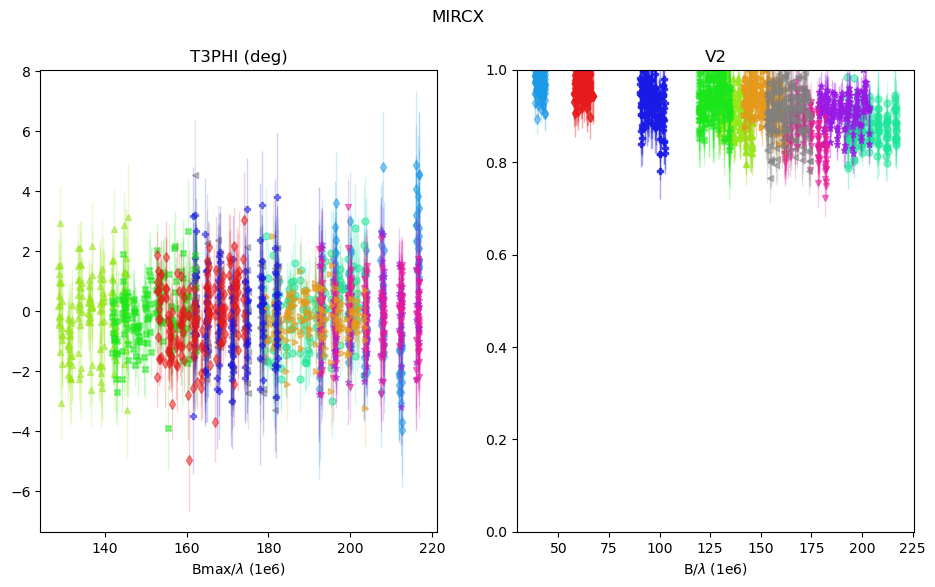

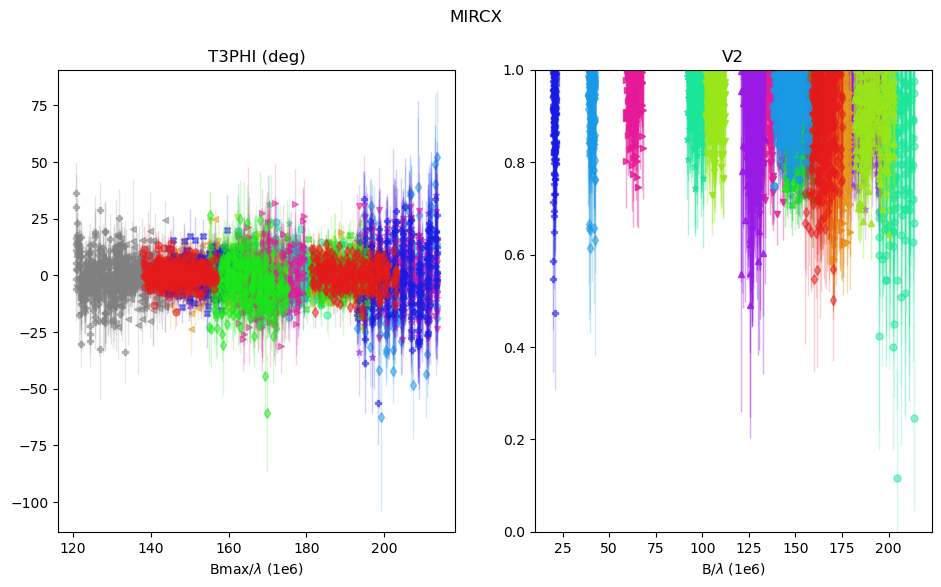

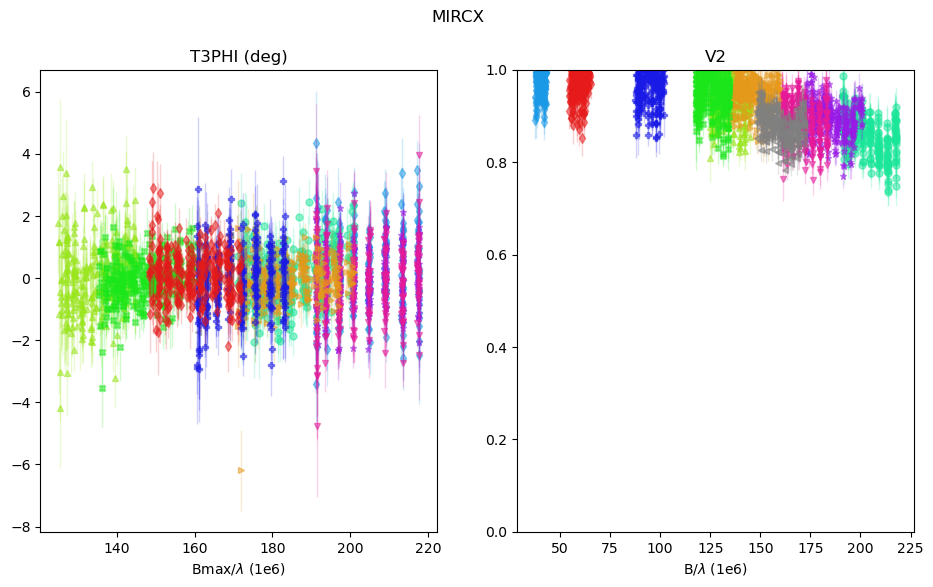

In [64]:
files = sorted(glob('data/12Vul/*.oifits'))

for i, file_path in enumerate(files, start=1):
    print('Plotting file:', file_path)
    oi = pmoired.OI(file_path, verbose=True)
    oi.setupFit({'obs': ['V2', 'T3PHI']})
    oi.show(spectro=False, showUV=False, fig=100 + i)

No obvious binary signature  looks like a single star, marginally resolved, in all three snapshots. But we should still check - sometimes a high-contrast companion signal is hard to see in the data. If not, then we will at least get brightness limits on the invisible companion.

Let's try to fit some models to the best dataset.

* Setup PMOIRED fit
* Setup PMOIRED model and starting guess values - Two UD components
* doFit - **assuming no companion at first (zero separation and flux) and just fit primary UD**
* show - display data and model

loadOI: loading data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "12 Vul" pipeline: ""
  > MJD: (26,) [59366.4112..59366.4258] ~2021-06-01T10:01:30.875
  > E1-E2-S1-W1-W2 | WL: (7,) [ 1.52 .. 1.708 ] um (R~55 P~52) {'T3': 10, 'VIS': 10, 'VIS2': 10} | TELL: False 
Fitting on: data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits
[dpfit] 1 FITTED parameters: ['A,ud']
[dpfit] epsfcn= 1e-06 ftol= 1e-05
[dpfit] using scipy.optimize.leastsq
[dpfit] Fri Mar 20 09:43:36 2026 001/001 CHI2: 1.2027e+00|
[dpfit] Both actual and predicted relative reductions in the sum of squares  are at most 0.000010
[dpfit] 7 function calls ( 1.583 ms on average)
# -- degrees of freedom: 3099
# -- reduced chi2: 1.0244659245368979
{'A,ud':0.2438, # +/- 0.0017
'A,f': 1.0,
'B,f': 0.0,
'B,ud':0.01,
'B,x': 0.0,
'B,y': 0.0,
}



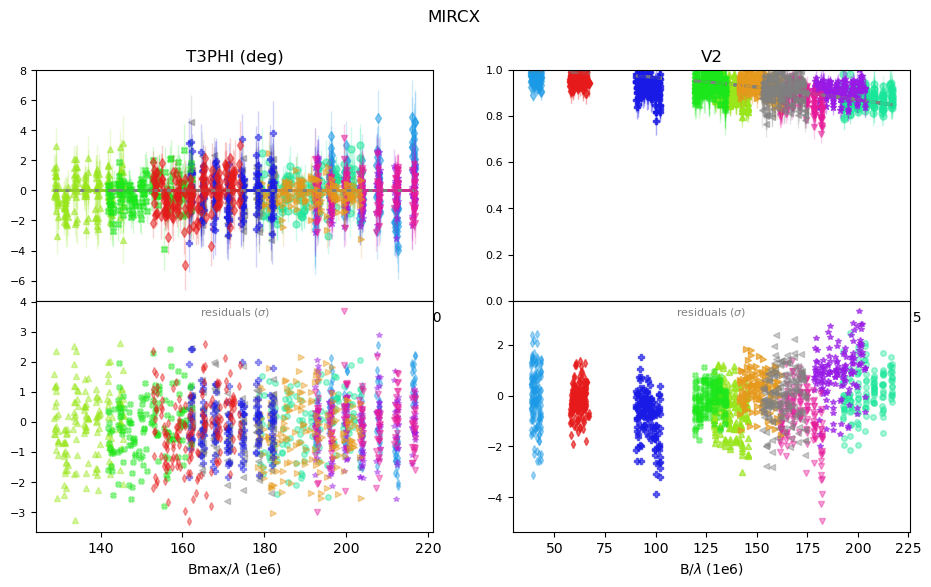

In [65]:
# -- setup and fit a binary model on one selected 12Vul file
file_path = 'data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits'
oi = pmoired.OI(file_path, verbose=True)
print('Fitting on:', file_path)

# Setup PMOIRED fit
fit = {
    'obs': ['T3PHI', 'V2'],
    'min error': {},
    'min relative error': {},
}
oi.setupFit(fit, update=False, debug=False)

# Setup PMOIRED model and starting guess values
model = {
    'A,ud': 0.2,
    'A,f': 1.0,
    'B,ud': 0.01,
    'B,f': 0.0,
    'B,x': 0.0,
    'B,y': 0.0,
}
do_not_fit = ['A,f', 'B,ud', 'B,f', 'B,x', 'B,y']

oi.doFit(
    model=model,
    fitOnly=None,
    doNotFit=do_not_fit,
    prior=None,
)

model = oi.bestfit['best'].copy()
model_ref = model.copy()

oi.show(
    model=model,
    spectro=False,
    showUV=False,
    imFov=None,
    imMax=0.05,
)

Model with a single marginally resolved component results in reduced chi2 ~ 1.0.

**It looks like we will not be able to improve the fit by letting the binary companion parameters converge.** But, let's try anyway and see what happens.

**gridFit - Running a grid of binary model fits**

- Define angular grid step and inner and outer angular separation limits. Outer limit is constrained by bandwidth smearing.
- Set up parameters to be fitted - separation, flux ratio, (UD diameter of primary if resolved), ...
- Set priors on fitted parameters - expected flux ratio

loadOI: loading data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "12 Vul" pipeline: ""
  > MJD: (26,) [59366.4112..59366.4258] ~2021-06-01T10:01:30.875
  > E1-E2-S1-W1-W2 | WL: (7,) [ 1.52 .. 1.708 ] um (R~55 P~52) {'T3': 10, 'VIS': 10, 'VIS2': 10} | TELL: False 
Grid-fit run on: data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits
step = 0.95 mas, lim_outer = 26.05 mas, lim_inner = 0.48 mas
125 grid points not within constraints
Fri Mar 20 09:43:39 2026: running 316 fits on 8 processes
Fri Mar 20 09:43:53 2026: [████████████████████████████████████████████████████████████]316/316   0s   left

Fri Mar 20 09:43:53 2026: it took 14.6s, 0.05s per fit on average [1300.4 fit/minute]
fits to be taken into account: 233 / 316
  83 did not numerically converge (incl 83 have no uncertainties)
Fri Mar 20 09:43:53 2026: making list of unique minima...
unique minima: 187 / 233 [~1.2 first guesses / minima]
  WARNING!: too many unique minima -> gr

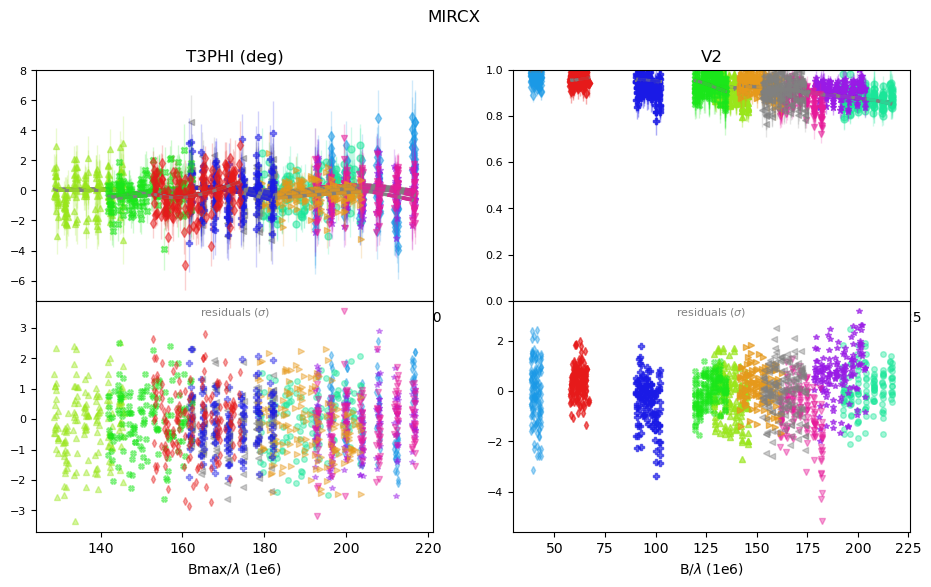

In [66]:
# -- run a binary grid search map on one selected 12Vul file
file_path = 'data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits'
oi = pmoired.OI(file_path, verbose=True)
print('Grid-fit run on:', file_path)

# lambda/B step (mas) and search radius from spectral resolution
step = 180 * 3600 * 1000e-6 / np.pi / max([
    np.max(oi.data[0]['OI_VIS2'][k]['B/wl']) for k in oi.data[0]['OI_VIS2']
])
R = np.mean(oi.data[0]['WL'] / oi.data[0]['dWL'])
lim_outer = R * step / 2
lim_inner = step / 2
print(f'step = {step:.2f} mas, lim_outer = {lim_outer:.2f} mas, lim_inner = {lim_inner:.2f} mas')

# manual overwrite of step and limits
step = 1.0
lim_outer = 10
lim_inner = 0.5

expl = {'grid': {'B,x': (-lim_outer, lim_outer, step), 'B,y': (-lim_outer, lim_outer, step)}}


oi.setupFit({'obs': ['T3PHI','V2']})

do_not_fit = ['A,f', 'B,ud']

oi.gridFit(
    expl,
    model=model,
    doNotFit=do_not_fit,
    constrain=[
        ('np.sqrt(B,x**2+B,y**2)', '<=', lim_outer),
        ('np.sqrt(B,x**2+B,y**2)', '>', lim_inner),
    ],
    prior=[('B,f', '<', 0.1)], # Expecting a high-contrast companion (f < 0.1)
)

model = oi.bestfit['best'].copy()

oi.show(
    model='best',
    spectro=False,
    showUV=False,
    perSetup=True,
    imFov=None,
    imMax=0.05,
)

WARNING!: too many unique minima -> grid too coarse / Nfits too small?  finding the global minimum may be unreliable

**showGrid - Visualizing the significance of the grid of fits delivered by gridFit**

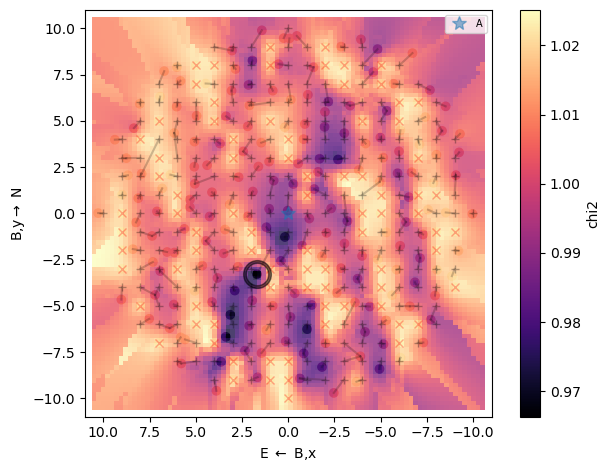

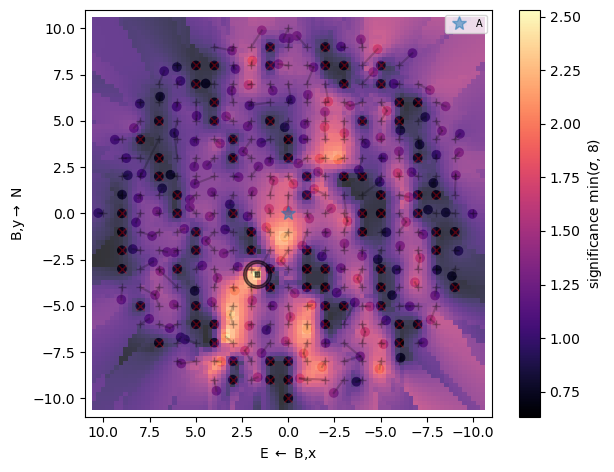

In [67]:
oi.showGrid(interpolate=True, tight=True)
oi.showGrid(interpolate=True, tight=True, significance=model_ref)

Very small variations in chi2 and minimum not well-defined - this does not look like a reliable detection. Let's look closely just at the closure phases for any hint of a signal and to avoid any possible bias from visibility miscalibration.

loadOI: loading data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "12 Vul" pipeline: ""
  > MJD: (26,) [59366.4112..59366.4258] ~2021-06-01T10:01:30.875
  > E1-E2-S1-W1-W2 | WL: (7,) [ 1.52 .. 1.708 ] um (R~55 P~52) {'T3': 10, 'VIS': 10, 'VIS2': 10} | TELL: False 
Grid-fit run on: data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits
step = 0.95 mas, lim_outer = 26.05 mas, lim_inner = 0.48 mas
125 grid points not within constraints
Fri Mar 20 09:43:58 2026: running 316 fits on 8 processes
Fri Mar 20 09:44:09 2026: [████████████████████████████████████████████████████████████]316/316   0s   left

Fri Mar 20 09:44:09 2026: it took 12.0s, 0.04s per fit on average [1581.8 fit/minute]
fits to be taken into account: 154 / 316
  154 did not numerically converge (incl 154 have no uncertainties)
  8 have uncertainties larger than the grid's step[s]
Fri Mar 20 09:44:10 2026: making list of unique minima...
unique minima: 125 / 154 [~1.2 first gu

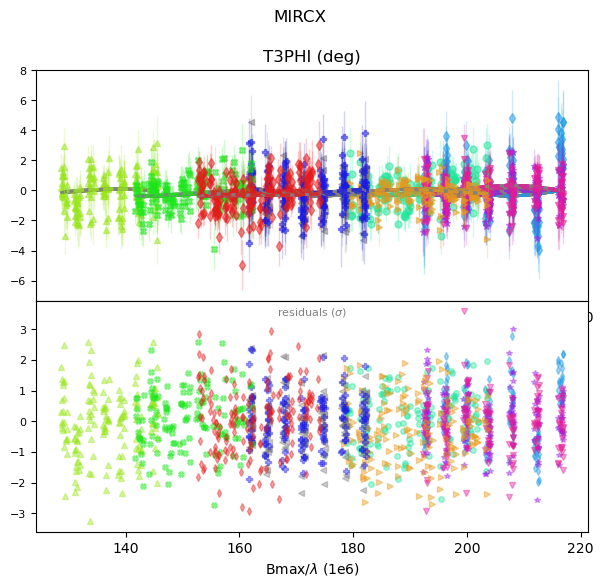

In [68]:
# -- run a binary grid search map on one selected 12Vul file
file_path = 'data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits'
oi = pmoired.OI(file_path, verbose=True)
print('Grid-fit run on:', file_path)

# lambda/B step (mas) and search radius from spectral resolution
step = 180 * 3600 * 1000e-6 / np.pi / max([
    np.max(oi.data[0]['OI_VIS2'][k]['B/wl']) for k in oi.data[0]['OI_VIS2']
])
R = np.mean(oi.data[0]['WL'] / oi.data[0]['dWL'])
lim_outer = R * step / 2
lim_inner = step / 2
print(f'step = {step:.2f} mas, lim_outer = {lim_outer:.2f} mas, lim_inner = {lim_inner:.2f} mas')

# manual overwrite of step and limits
step = 1.0
lim_outer = 10
lim_inner = 0.5

expl = {'grid': {'B,x': (-lim_outer, lim_outer, step), 'B,y': (-lim_outer, lim_outer, step)}}


oi.setupFit({'obs': ['T3PHI']})

do_not_fit = ['A,f', 'A,ud', 'B,ud']

oi.gridFit(
    expl,
    model=model,
    doNotFit=do_not_fit,
    constrain=[
        ('np.sqrt(B,x**2+B,y**2)', '<=', lim_outer),
        ('np.sqrt(B,x**2+B,y**2)', '>', lim_inner),
    ],
    prior=[('B,f', '<', 0.1)], # Expecting a high-contrast companion (f < 0.1)
)

model = oi.bestfit['best'].copy()
oi.show(
    model='best',
    spectro=False,
    showUV=False,
    perSetup=True,
    imFov=None,
    imMax=0.05,
)

Marginal improvement in chi2, but the fitted companion is extremely faint - signal in CP of the order of 0.1 deg or less.

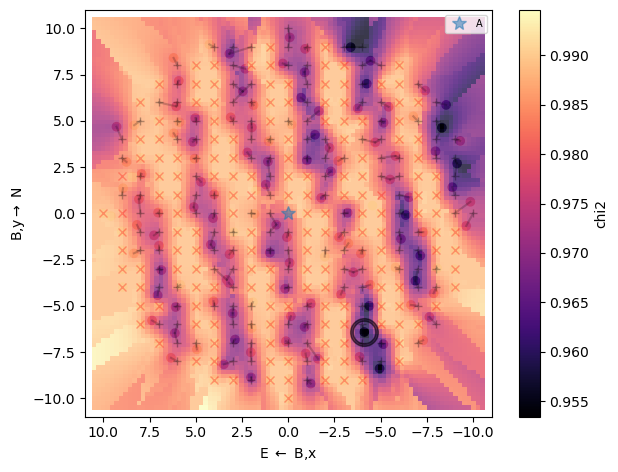

In [69]:
oi.showGrid(interpolate=True, tight=True)

**This is not a detection. All we can get from this particular snapshot is a lower limit on the flux/magnitude difference between the primary and the possible companion**. There can always be fainter companions than our data can see, and same goes for the angular separation limits. For certain orientation of binary orbits, the components can also be too close to each other at a certain epoch, resulting in a non-detection, while at another time the binary can be clearly detected.

**------------------------------------------------------------**

**DETECTION LIMIT FOR NON-DETECTIONS**

**detLim - Lower limit on the magnitude difference between the primary and an undetected companion**

Injecting the companion into the data at random positions within given intervals to get the companion flux needed to obtain a detection (in terms of chi2).

Detection-limit run on: data/12Vul/MIRCX_L2.2021Jun01.12_Vul.MIRCX_IDL.1.SPLIT.oifits
114 grid points not within constraints
Fri Mar 20 09:44:12 2026: running 386 fits on 8 processes
Fri Mar 20 09:44:20 2026: [████████████████████████████████████████████████████████████]386/386   0s   left

Fri Mar 20 09:44:20 2026: it took 8.8s, 0.02s per fit on average [2641.6 fit/minute]
distribution of 3.0sigma detections:
 median B,f : 0.0044 
 1sigma (68%) 0.0031 -> 0.0064
        (90%) 0.0025 -> 0.0090
 2sigma (95%) 0.0022 -> 0.0144
        (99%) 0.0020 -> 0.0201
distribution of 3.0sigma detections:
 median B,f : 5.8964 mag
 1sigma (68%) 5.4837 -> 6.2662
        (90%) 5.1196 -> 6.5049
 2sigma (95%) 4.6070 -> 6.6328
        (99%) 4.2398 -> 6.7238


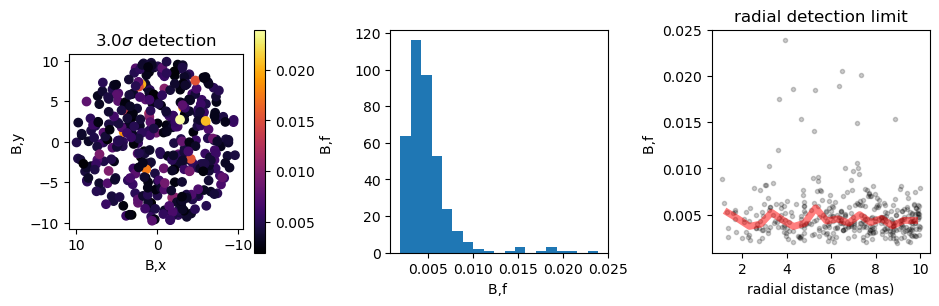

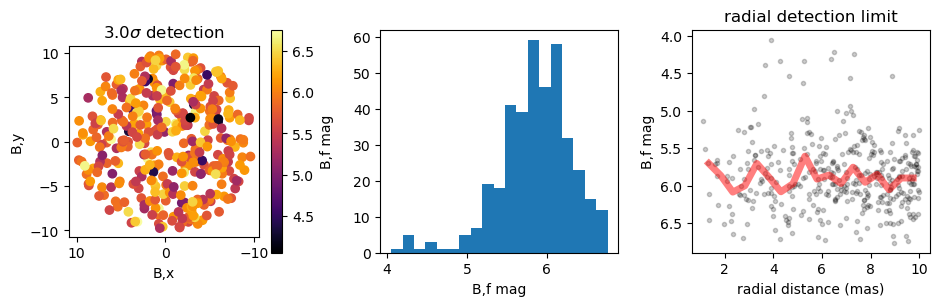

In [70]:
# -- run a 3-sigma detection-limit map on one selected 12Vul file
print('Detection-limit run on:', file_path)

# manual overwrite of step and limits
step = 1.0
lim_inner = 1.0
lim_outer = 10


expl = {'rand': {'B,x': (-lim_outer, lim_outer), 'B,y': (-lim_outer, lim_outer)}}
constrain = [
    ('np.sqrt(B,x**2+B,y**2)', '<=', lim_outer),
    ('np.sqrt(B,x**2+B,y**2)', '>', lim_inner),
]

oi.detectionLimit(
    expl,
    'B,f',
    model=model,
    Nfits=500,
    nsigma=3, # simulating 3-sigma detection of a point-source companion
    constrain=constrain,
)

oi.showLimGrid(mag=False)

oi.showLimGrid(mag=True)

**Understanding detLim output**

```python
distribution of 3.0sigma detections:
 median B,f : 5.6774 mag
 1sigma (68%) 5.2860 -> 5.9567
        (90%) 4.9895 -> 6.2242
 2sigma (95%) 4.8625 -> 6.2924
        (99%) 4.3733 -> 6.3902
```

- Median magnitude difference at which the injected companion is detected with 3-sigma confidence is **5.7 mag** (H band).
- 68% of injected companions were detected when fainter by 5.3 to 6.0 mag.
- ...
- 99% of injected companions were detected when fainter by 4.4 to 6.4 mag.

The median magnitude difference of a 3-sigma companion can be used as a realistic detection limit (same as in CANDID). From the distributions, one can take the *brightest detection events* as the detection limit.

The best is to write explicitly, for example: **50% (resp. 90%) of the injected companions were detected at 3 sigma level if brighter than delta(H) = 5.7 (resp. 5.0) mag compared to the primary.**

**------------------------------------------------------------**

**FITTING LOW-CONTRAST BINARIES**

V742 Cas - Be + bloated pre-sdOB binary candidate - now confirmed with data published in 2025A&A...694A.172R.

loadOI: loading data/V742Cas/MIRCX_L2.2022Aug27.HD_698.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "HD 698" pipeline: ""
  > MJD: (21,) [59818.3975..59818.4019] ~2022-08-27T09:35:22.184
  > E1-E2-S1-S2-W1-W2 | WL: (6,) [ 1.55 .. 1.707 ] um (R~56 P~52) {'T3': 20, 'VIS': 15, 'VIS2': 15} | TELL: False 
Fitting on: data/V742Cas/MIRCX_L2.2022Aug27.HD_698.MIRCX_IDL.1.SPLIT.oifits
[dpfit] 1 FITTED parameters: ['A,ud']
[dpfit] epsfcn= 1e-06 ftol= 1e-05
[dpfit] using scipy.optimize.leastsq
[dpfit] Fri Mar 20 09:44:21 2026 001/001 CHI2: 2.0686e+02|
[dpfit] Both actual and predicted relative reductions in the sum of squares  are at most 0.000010
[dpfit] 17 function calls ( 1.565 ms on average)
# -- degrees of freedom: 2082
# -- reduced chi2: 49.489226321398036
{'A,ud':1.014, # +/- 0.012
'A,f': 1.0,
'B,f': 0.5,
'B,ud':0.05,
'B,x': 0.0,
'B,y': 0.0,
}



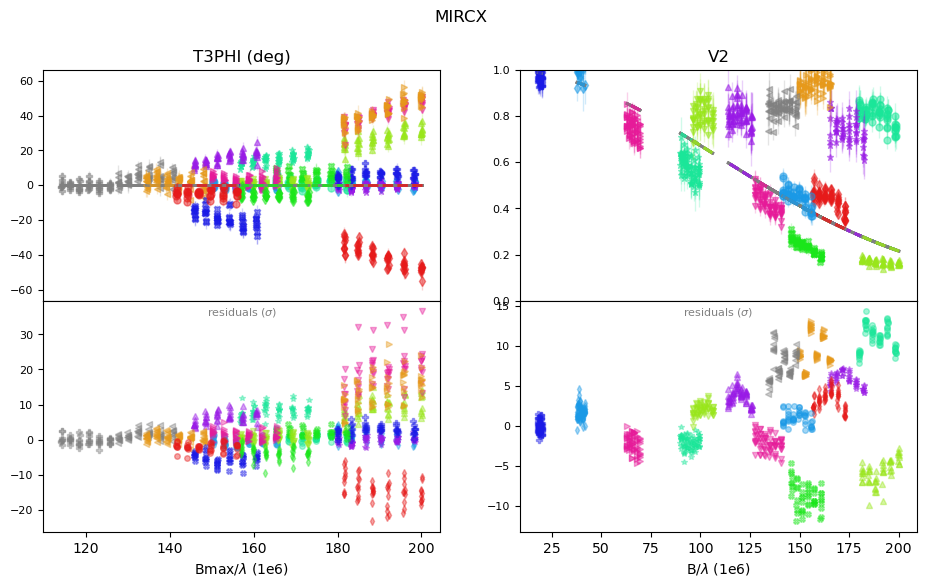

In [71]:
# -- setup and fit a binary model on one selected V742 Cas file
file_path = 'data/V742Cas/MIRCX_L2.2022Aug27.HD_698.MIRCX_IDL.1.SPLIT.oifits'
oi = pmoired.OI(file_path, verbose=True)
print('Fitting on:', file_path)

# Setup PMOIRED fit
fit = {
    'obs': ['T3PHI', 'V2'],
    'min error': {},
    'min relative error': {},
}
oi.setupFit(fit, update=False, debug=False)

# Setup PMOIRED model and starting guess values
model = {
    'A,ud': 0.1,
    'A,f': 1.0,
    'B,ud': 0.05,
    'B,f': 0.5,
    'B,x': 0.0,
    'B,y': 0.0,
}
do_not_fit = ['A,f', 'B,ud', 'B,f', 'B,x', 'B,y']

oi.doFit(
    model=model,
    fitOnly=None,
    doNotFit=do_not_fit,
    prior=[('A,ud', '<', 0.2)], # Expecting unresolved components
)

model = oi.bestfit['best'].copy()
model_ref = model.copy()

oi.show(
    model=model,
    spectro=False,
    showUV=False,
    imFov=None,
    imMax=0.05,
)

Looks like a **very close, low-constrast binary with unresolved components** (or at most marginally resolved). Let's run a narrow gridFit with two unresolved components.

loadOI: loading data/V742Cas/MIRCX_L2.2022Aug27.HD_698.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "HD 698" pipeline: ""
  > MJD: (21,) [59818.3975..59818.4019] ~2022-08-27T09:35:22.184
  > E1-E2-S1-S2-W1-W2 | WL: (6,) [ 1.55 .. 1.707 ] um (R~56 P~52) {'T3': 20, 'VIS': 15, 'VIS2': 15} | TELL: False 
Grid-fit run on: data/V742Cas/MIRCX_L2.2022Aug27.HD_698.MIRCX_IDL.1.SPLIT.oifits
step = 1.03 mas, lim_outer = 28.60 mas, lim_inner = 0.52 mas
40 grid points not within constraints
Fri Mar 20 09:44:23 2026: running 81 fits on 8 processes
Fri Mar 20 09:44:33 2026: [████████████████████████████████████████████████████████████]81/81   0s   left

Fri Mar 20 09:44:33 2026: it took 9.6s, 0.12s per fit on average [507.0 fit/minute]
fits to be taken into account: 81 / 81
Fri Mar 20 09:44:33 2026: making list of unique minima...
unique minima: 60 / 81 [~1.4 first guesses / minima]
  WARNING!: too many unique minima -> grid too coarse / Nfits too small?  finding the global minimum may be u

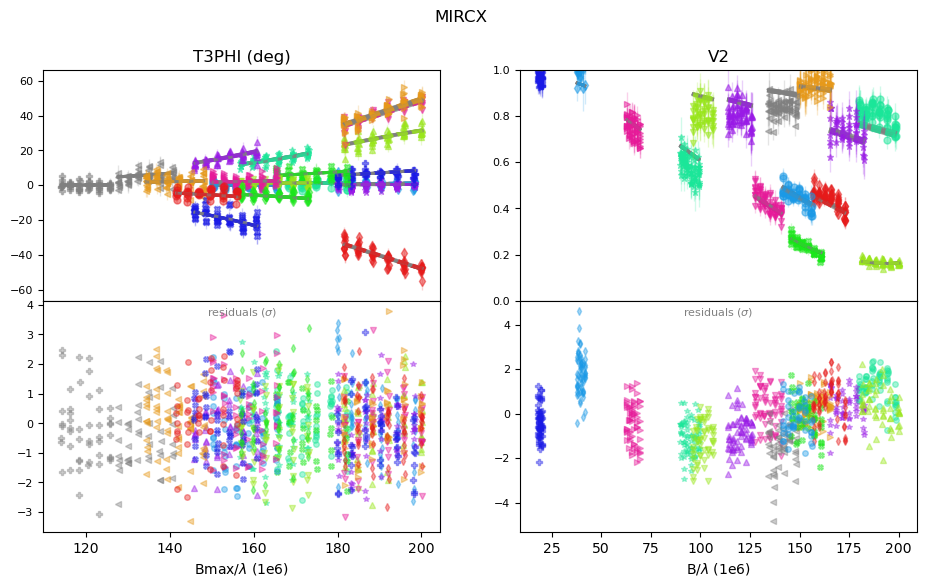

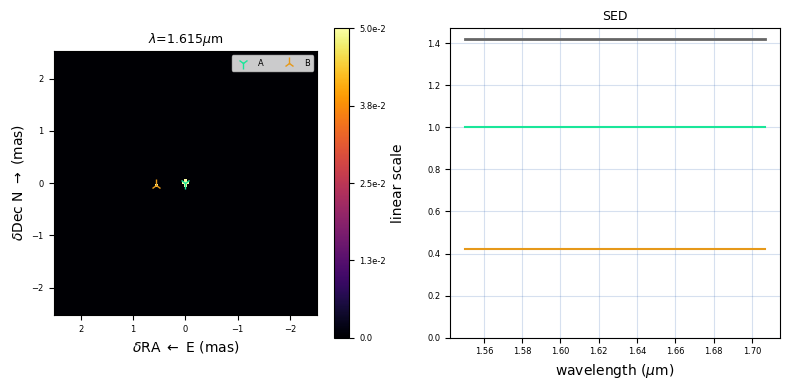

In [72]:
# -- run a binary grid search map on one selected V742 Cas file
file_path = 'data/V742Cas/MIRCX_L2.2022Aug27.HD_698.MIRCX_IDL.1.SPLIT.oifits'
oi = pmoired.OI(file_path, verbose=True)
print('Grid-fit run on:', file_path)

# lambda/B step (mas) and search radius from spectral resolution
step = 180 * 3600 * 1000e-6 / np.pi / max([
    np.max(oi.data[0]['OI_VIS2'][k]['B/wl']) for k in oi.data[0]['OI_VIS2']
])
R = np.mean(oi.data[0]['WL'] / oi.data[0]['dWL'])
lim_outer = R * step / 2
lim_inner = step / 2
print(f'step = {step:.2f} mas, lim_outer = {lim_outer:.2f} mas, lim_inner = {lim_inner:.2f} mas')

# manual overwrite of step and limits
step = 1.0
lim_outer = 5
lim_inner = 0.0

expl = {'grid': {'B,x': (-lim_outer, lim_outer, step), 'B,y': (-lim_outer, lim_outer, step)}}


oi.setupFit({'obs': ['T3PHI','V2']})

# Setup PMOIRED model and starting guess values
model = {
    'A,ud': 0.1,
    'A,f': 1.0,
    'B,ud': 0.05,
    'B,f': 0.5,
    'B,x': 0.0,
    'B,y': 0.0,
}
do_not_fit = ['A,f', 'A,ud', 'B,ud']

oi.gridFit(
    expl,
    model=model,
    doNotFit=do_not_fit,
    constrain=[
        ('np.sqrt(B,x**2+B,y**2)', '<=', lim_outer),
        ('np.sqrt(B,x**2+B,y**2)', '>', lim_inner),
    ],
    prior=[('A,ud', '<', 0.3)], # Expecting unresolved components
)

model = oi.bestfit['best'].copy()
oi.show(
    model='best',
    spectro=False,
    showUV=False,
    perSetup=True,
    imFov=5,
    imMax=0.05,
)

The grid step sometimes needs to be adjusted from the recommended value.

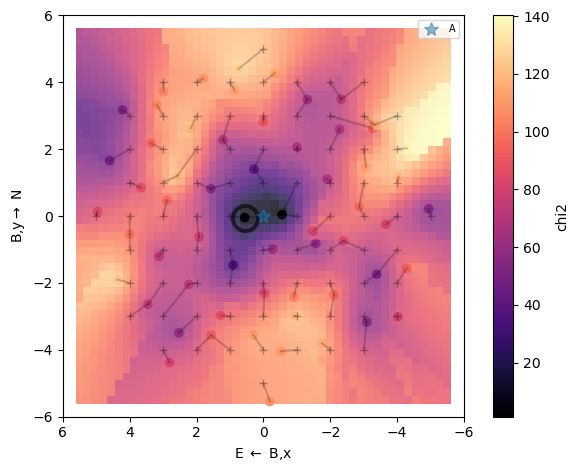

In [73]:
oi.showGrid(interpolate=True, tight=True)

We are pushing the angular resolution limit of the data here - the minimum appears extended, but it is still well-defined thanks to long CHARA baselines. Let's run bootstrapping to get the error ellipse for the astrometric position.

Fri Mar 20 09:44:35 2026: running 500 fits on 8 processes
Fri Mar 20 09:44:49 2026: [████████████████████████████████████████████████████████████]500/500   0s   left
Fri Mar 20 09:44:49 2026: it took 13.5s, 0.03s per fit on average [2225.3 fit/minutes]
{'B,f': 0.4199, # +0.0022 -0.0017
'B,x': 0.55859, # +/- 0.00090
'B,y': -0.0426, # +/- 0.0016
'A,f': 1.0,
'A,ud':0.1,
'B,ud':0.05,
}

Correlations (%)  >=95 >=90 >=80 >=60 <60%
        0   1   2  
 0:B,f ### -74   8   4 
 1:B,x -74 ### -51  -6 
 2:B,y   8 -51 ###   0 
ellipse (emin, emax, PA) for B,x/B,y: 0.0008 0.0016 -24.4


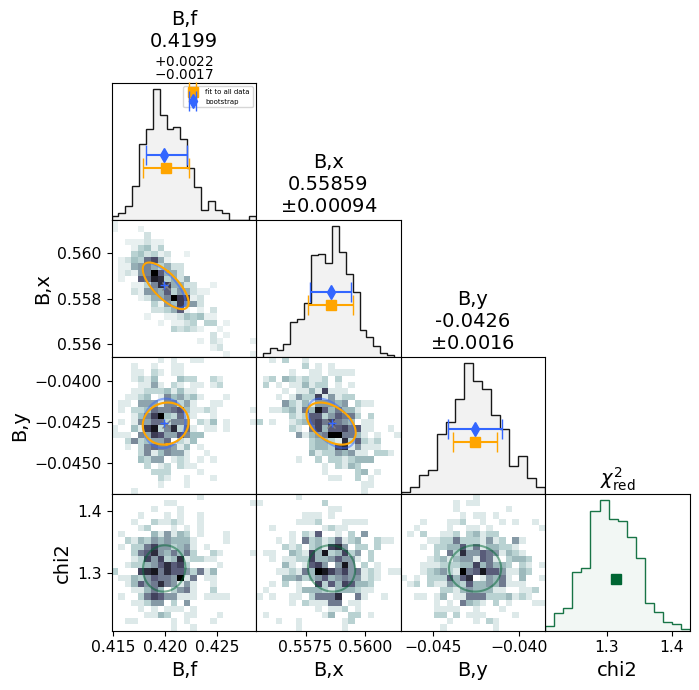

In [74]:
oi.bootstrapFit(Nfits=500)

oi.showBootstrap(showChi2=True)

The final orbital solution combining 6 MIRC-X/MYSTIC epochs looks good.

<img src="plot_orbit_V742Cas.png" style="width:50%;">

**alf Psc B - wide equal flux binary**

Wide binaries may require very long gridFit runs. The fielf of view increases with spectral resolution due to less bandwidth smearing - but higher spectral resolution also results in longer computation. Rebin your data to lower spectral resolution if you don't need to search wide!

loadOI: loading data/alfPsc/MYSTIC_L2.2025Aug31.alf_Psc.MIRCX_IDL.2025Sep25.SPLIT.oifits
  > insname: "MIRCX" targname: "alf Psc" pipeline: ""
  > MJD: (53,) [60918.4127..60918.4321] ~2025-08-31T10:15:22.678
  > E1-E2-S1-S2-W1-W2 | WL: (19,) [ 2.002 .. 2.376 ] um (R~107 P~106) {'T3': 20, 'VIS': 15, 'VIS2': 15} | TELL: False 
Fitting on: data/alfPsc/MYSTIC_L2.2025Aug31.alf_Psc.MIRCX_IDL.2025Sep25.SPLIT.oifits
[dpfit] 5 FITTED parameters: ['A,ud', 'B,f', 'B,ud', 'B,x', 'B,y']
[dpfit] epsfcn= 1e-06 ftol= 1e-05
[dpfit] using scipy.optimize.leastsq
[dpfit] Fri Mar 20 09:44:50 2026 001/000 CHI2: 5.1322e+00|
[dpfit] Both actual and predicted relative reductions in the sum of squares  are at most 0.000010
[dpfit] 105 function calls ( 2.633 ms on average)
[dpfit] Parameters ['A,ud', 'B,ud', 'B,x', 'B,y'] may not be converging properly
[dpfit] check with "showFit" (too sensitive to relative variations?)
# -- degrees of freedom: 9890
# -- reduced chi2: 1.583749239639307
{'A,ud':0.3407, # +/- 0.00

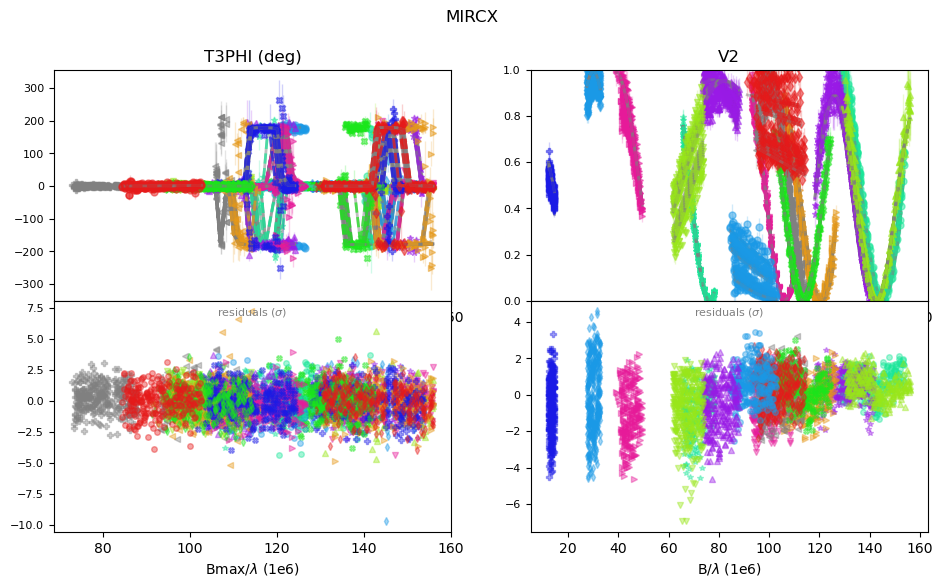

In [75]:
# -- setup and fit a binary model on one selected 12Vul file
file_path = 'data/alfPsc/MYSTIC_L2.2025Aug31.alf_Psc.MIRCX_IDL.2025Sep25.SPLIT.oifits'
oi = pmoired.OI(file_path, verbose=True)
print('Fitting on:', file_path)

# Setup PMOIRED fit
fit = {
    'obs': ['T3PHI', 'V2'],
    'min error': {},
    'min relative error': {},
}
oi.setupFit(fit, update=False, debug=False)

# Setup PMOIRED model and starting guess values
model = {
    'A,ud': 0.34,
    'A,f': 1.0,
    'B,ud': 0.30,
    'B,f': 0.99,
    'B,x': 5.7,
    'B,y': 3.9,
}
do_not_fit = ['A,f']

oi.doFit(
    model=model,
    fitOnly=None,
    doNotFit=do_not_fit,
    prior=None,
)
model = oi.bestfit['best'].copy()

oi.show(
    model=model,
    spectro=False,
    showUV=False,
    imFov=None,
    imMax=0.05,
)

**Which star is which in low-contrast binaries?** If they differ in their (near-IR) spectra, we can use interferometry in high spectral resolution to distinguish them (see the other notebook).

**------------------------------------------------------------**

**FITTING LOW-CONTRAST BINARIES**

**kap Dra** - classical Be + subdwarf B-type binary (published in 2022ApJ...940...86K)

loadOI: loading data/kapDra/MYSTIC_L2.2021Dec18.kap_Dra.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "kap Dra" pipeline: ""
  > MJD: (36,) [59566.5052..59566.5183] ~2021-12-18T12:15:55.404
  > E1-E2-S2-W1-W2 | WL: (8,) [ 2.017 .. 2.318 ] um (R~53 P~51) {'T3': 10, 'VIS': 10, 'VIS2': 10} | TELL: False 
Fitting on: data/kapDra/MYSTIC_L2.2021Dec18.kap_Dra.MIRCX_IDL.1.SPLIT.oifits
[dpfit] 1 FITTED parameters: ['A,ud']
[dpfit] epsfcn= 1e-06 ftol= 1e-05
[dpfit] using scipy.optimize.leastsq
[dpfit] Both actual and predicted relative reductions in the sum of squares  are at most 0.000010
[dpfit] 7 function calls ( 2.13 ms on average)
# -- degrees of freedom: 3869
# -- reduced chi2: 2.4005169064581704
{'A,ud':0.5472, # +/- 0.0026
'A,f': 1.0,
'B,f': 0.5,
'B,ud':0.05,
'B,x': 0.0,
'B,y': 0.0,
}



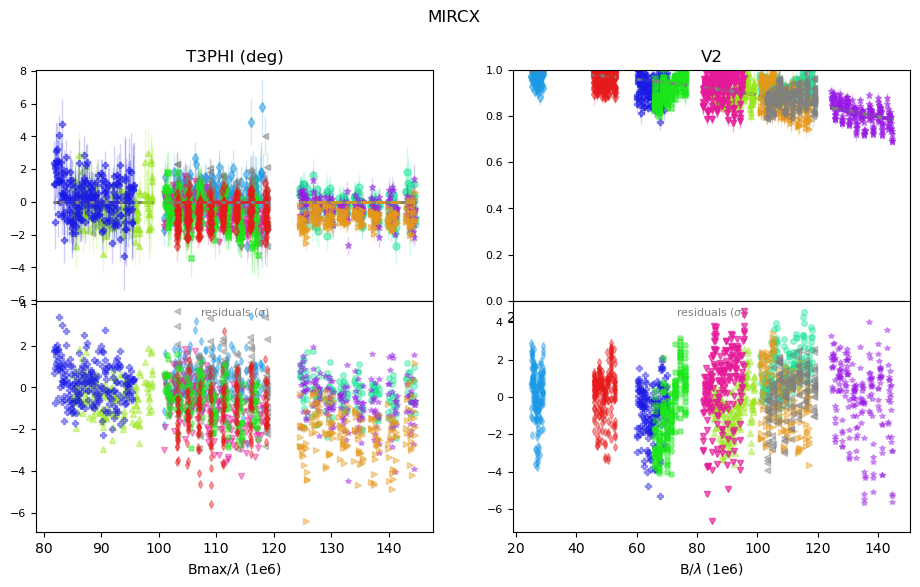

In [76]:
# -- setup and fit a binary model on one selected 12Vul file
file_path = 'data/kapDra/MYSTIC_L2.2021Dec18.kap_Dra.MIRCX_IDL.1.SPLIT.oifits'
oi = pmoired.OI(file_path, verbose=True)
print('Fitting on:', file_path)

# Setup PMOIRED fit
fit = {
    'obs': ['T3PHI', 'V2'],
    'min error': {},
    'min relative error': {},
}
oi.setupFit(fit, update=False, debug=False)

# Setup PMOIRED model and starting guess values
model = {
    'A,ud': 0.4,
    'A,f': 1.0,
    'B,ud': 0.05,
    'B,f': 0.5,
    'B,x': 0.0,
    'B,y': 0.0,
}
do_not_fit = ['A,f', 'B,ud', 'B,f', 'B,x', 'B,y']

oi.doFit(
    model=model,
    fitOnly=None,
    doNotFit=do_not_fit,
    prior=None,
)
model = oi.bestfit['best'].copy()
model_ref = model

oi.show(
    model=model,
    spectro=False,
    showUV=False,
    imFov=None,
    imMax=0.05,
)

**Looks similar to the first star which was a non-detection. Let's run gridFit.**

*The Be star and its disk are marginally resolved - if a resolved disk is inclined, the visibility curve will be split into two, and we can no longer use the visibilities assuming a simple point source or a UD. Here, the disk is small and seen close to pole-on, and therefore no asymmetry is introduced in the visibilities and we can just proceed with assuming UD for the Be star. For a more resolved, inclined disk, you can introduce additional model components for the disk or replace UD with an inclined Gaussian, for instance. Beware of correlation between the disk and companion parameters.*

loadOI: loading data/kapDra/MYSTIC_L2.2021Dec18.kap_Dra.MIRCX_IDL.1.SPLIT.oifits
  > insname: "MIRCX" targname: "kap Dra" pipeline: ""
  > MJD: (36,) [59566.5052..59566.5183] ~2021-12-18T12:15:55.404
  > E1-E2-S2-W1-W2 | WL: (8,) [ 2.017 .. 2.318 ] um (R~53 P~51) {'T3': 10, 'VIS': 10, 'VIS2': 10} | TELL: False 
Grid-fit run on: data/kapDra/MYSTIC_L2.2021Dec18.kap_Dra.MIRCX_IDL.1.SPLIT.oifits
step = 1.43 mas, lim_outer = 38.16 mas, lim_inner = 0.71 mas
124 grid points not within constraints
Fri Mar 20 09:44:55 2026: running 317 fits on 8 processes
Fri Mar 20 09:45:15 2026: [████████████████████████████████████████████████████████████]317/317   0s   left

Fri Mar 20 09:45:15 2026: it took 19.8s, 0.06s per fit on average [962.7 fit/minute]
fits to be taken into account: 202 / 317
  96 did not numerically converge (incl 96 have no uncertainties)
  19 have uncertainties larger than the grid's step[s]
Fri Mar 20 09:45:15 2026: making list of unique minima...
unique minima: 52 / 202 [~3.9 fir

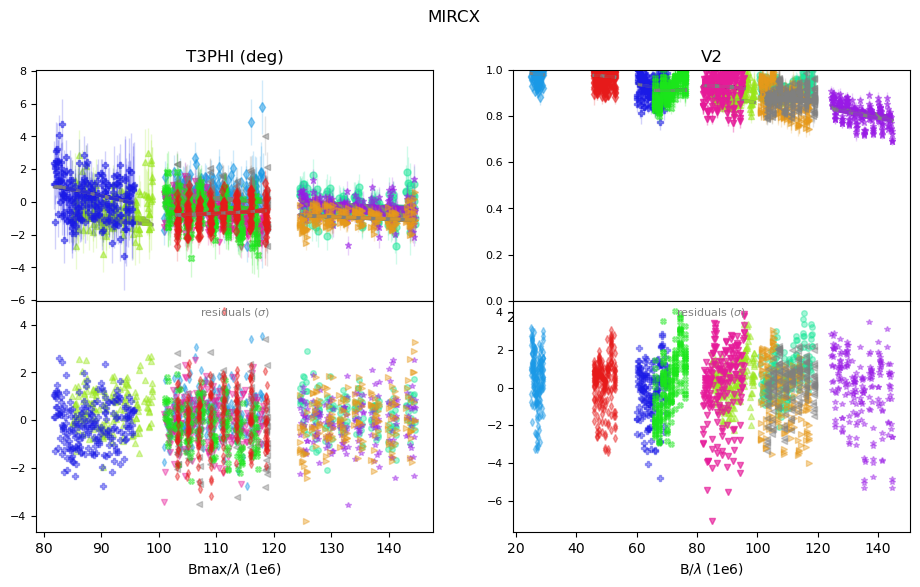

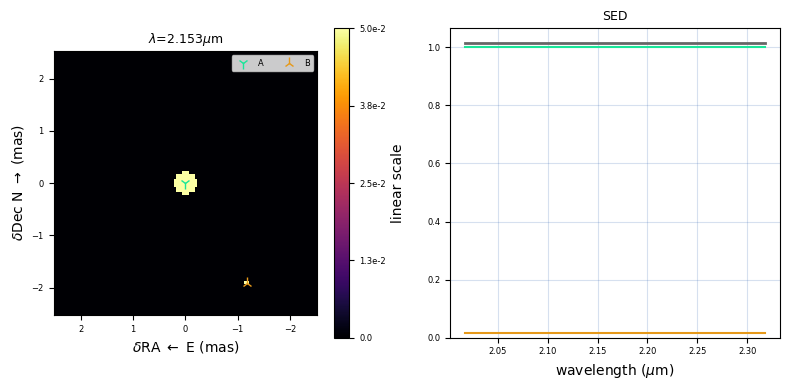

In [77]:
# -- run a binary grid search map on one selected kapDra file
file_path = 'data/kapDra/MYSTIC_L2.2021Dec18.kap_Dra.MIRCX_IDL.1.SPLIT.oifits'
oi = pmoired.OI(file_path, verbose=True)
print('Grid-fit run on:', file_path)

# lambda/B step (mas) and search radius from spectral resolution
step = 180 * 3600 * 1000e-6 / np.pi / max([
    np.max(oi.data[0]['OI_VIS2'][k]['B/wl']) for k in oi.data[0]['OI_VIS2']
])
R = np.mean(oi.data[0]['WL'] / oi.data[0]['dWL'])
lim_outer = R * step / 2
lim_inner = step / 2
print(f'step = {step:.2f} mas, lim_outer = {lim_outer:.2f} mas, lim_inner = {lim_inner:.2f} mas')

# manual overwrite of step and limits
step = 0.8
lim_outer = 8
lim_inner = 0.0

expl = {'grid': {'B,x': (-lim_outer, lim_outer, step), 'B,y': (-lim_outer, lim_outer, step)}}


oi.setupFit({'obs': ['T3PHI','V2']})

do_not_fit = ['A,f', 'B,ud']

oi.gridFit(
    expl,
    model=model,
    doNotFit=do_not_fit,
    constrain=[
        ('np.sqrt(B,x**2+B,y**2)', '<=', lim_outer),
        ('np.sqrt(B,x**2+B,y**2)', '>', lim_inner),
    ],
    prior=[('B,f', '<', 0.1)], # High-contrast binary (f < 0.1) or non-detection?
)

model = oi.bestfit['best'].copy()
oi.show(
    model='best',
    spectro=False,
    showUV=False,
    perSetup=True,
    imFov=5,
    imMax=0.05,
)

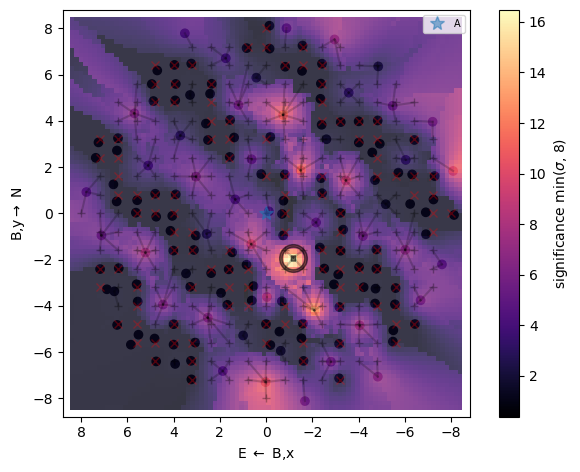

In [78]:
oi.showGrid(interpolate=True, tight=True, significance=model_ref)

Fri Mar 20 09:45:19 2026: running 500 fits on 8 processes
Fri Mar 20 09:45:41 2026: [████████████████████████████████████████████████████████████]500/500   0s   left
Fri Mar 20 09:45:41 2026: it took 22.4s, 0.04s per fit on average [1339.0 fit/minutes]
{'A,ud':0.4014, # +/- 0.0054
'B,f': 0.01485, # +/- 0.00040
'B,x': -1.1753, # +/- 0.0095
'B,y': -1.914, # +/- 0.012
'A,f': 1.0,
'B,ud':0.05,
}

Correlations (%)  >=95 >=90 >=80 >=60 <60%
         0   1   2   3  
 0:A,ud ### -20  11 -23  50 
 1: B,f -20 ###  47  -9   7 
 2: B,x  11  47 ### -44  19 
 3: B,y -23  -9 -44 ###  -5 
ellipse (emin, emax, PA) for B,x/B,y: 0.0078 0.0135 -29.3


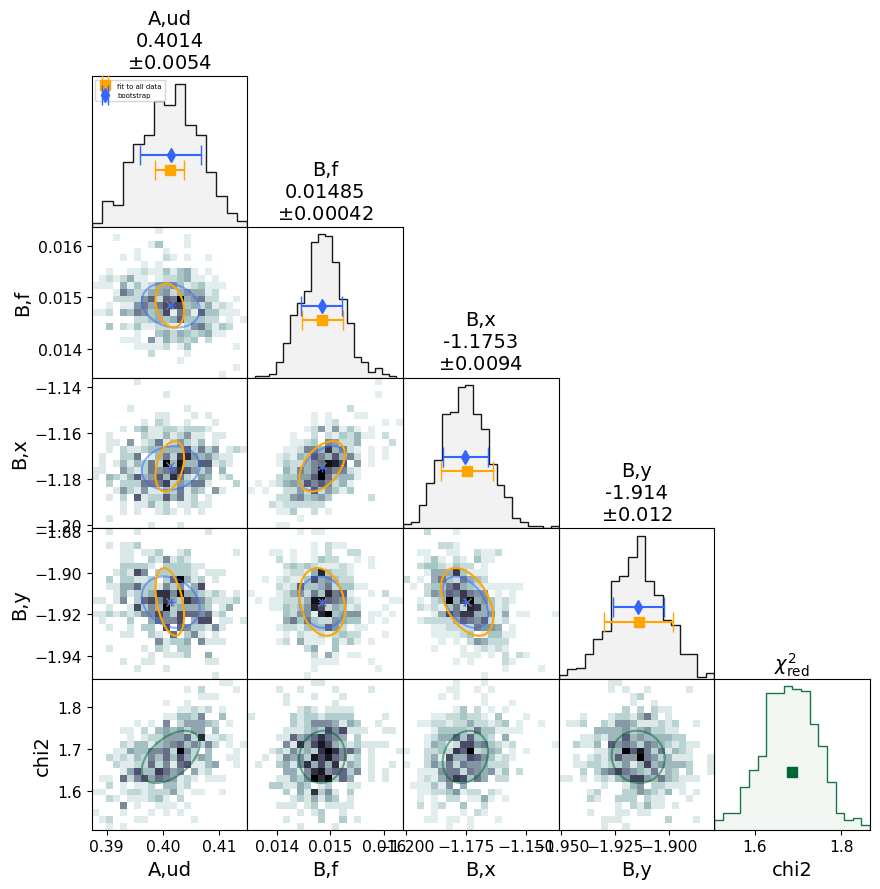

In [79]:
oi.bootstrapFit(Nfits=500)

oi.showBootstrap(showChi2=True)

<img src="plot_orbit_kapDra.png" style="width:50%;">

**If you have good data and a binary within the appropriate ranges, PMOIRED gridFit will work like a charm.** Conservative limits:
- CHARA - snapshot detection from 5T/6T data if f2/f1 > 0.5%, and 0.5 mas < ang_sep < BW-smearing FoV
- VLTI - snapshot detection from 4T data if f2/f1 > 1.0%, and 1.0 mas < ang_sep < BW-smearing FoV

**CHARA is better suited for binary detections (ignoring average observing conditions, ...) with its better uv coverage and higher angular resolution**

**Hints for tentative detections**:

- Need to confirm with a second beam combiner (MIRC-X+MYSTIC) or with multi-epoch observations
- Use the best-quality snapshot to estimate the flux ratio, and fix it for lower-quality data
- Use priors for flux ratio and separation based on estimates from spectroscopy, photometry, ...
- Try for orbital solution - the astrometry needs to line up to be compatible with a keplerian orbit - easy to identify outliers!
- Use common sense not to overfit data

**Other hints**:

- If your target is resolved and asymmetric, use a more complicated model than UD to represent it (for instance UD + inclined Gaussian to represent a star with disk) and then use gridSearch as usual. Be careful of too many free parameters slowing things down.
- Check the covariance matrix for correlations between parameters. Bootstrap may crash for highly correlated parameters - need to fix one of them.
- Rebin data as needed to speed up the fit and to adjust how wide you can search
- You can search beyond the BW-smearing FoV - companions can still be detected if bright enough.
- Try different step and limits for gridSearch
- Stick to T3PHI if V2 looks noisy or miscalibrated.